In [1]:
suppressMessages(library(DESeq2))
suppressMessages(library(data.table))
suppressMessages(library(ggplot2))
suppressMessages(library(ggrepel))
suppressMessages(library(dplyr))
suppressMessages(library(AnnotationHub))
suppressMessages(library(biomaRt))
suppressMessages(library(pheatmap))
suppressMessages(library(RColorBrewer))
suppressMessages(library(tidyr))
suppressMessages(library(org.Hs.eg.db))
suppressMessages(library(tibble))
suppressMessages(library(EnhancedVolcano))
suppressMessages(library(ggpubr))
suppressMessages(library(cluster))
suppressMessages(library(EnsDb.Hsapiens.v86))
suppressMessages(library(clusterProfiler))
suppressMessages(library(GO.db))
suppressMessages(library(forcats))
suppressMessages(library(enrichplot))
suppressMessages(library(limma))
suppressMessages(library(rtracklayer))
suppressMessages(library(rstatix))
suppressMessages(library(ggpubr))

In [2]:
colors <- c("Neuron" = "#E07A7A", "Glia" = "#D08AD0", "NPC" = "#7FBF7B", "iPSC" = "#E6A85C", "GSC" = "#4D7F7F", 
           "MSC" = "#b66dff", "hESC" = "009E73", "HPSC" = "#CC79A7", "GPC" = "#E69F00", 
           "Tumor" = "#123B6E", "Non-matched cell lines" = "#8CC0E7", "Matched cell lines" = "#2E75B6")

In [3]:
gtf <- import("Homo_sapiens.GRCh38.113.gtf.gz")
annotation_table <- as.data.frame(gtf) %>%
  filter(type == "transcript") %>%
  transmute(
    ensembl_transcript_id = transcript_id,
    ensembl_gene_id = gene_id,
    hgnc_symbol = gene_name
  ) %>%
  distinct()
colnames(annotation_table)[colnames(annotation_table) == "hgnc_symbol"] <- "symbol"
head(annotation_table)

,ensembl_transcript_id,ensembl_gene_id,symbol
,<chr>,<chr>,<chr>
1,ENST00000511072,ENSG00000142611,PRDM16
2,ENST00000607632,ENSG00000142611,PRDM16
3,ENST00000378391,ENSG00000142611,PRDM16
4,ENST00000514189,ENSG00000142611,PRDM16
5,ENST00000270722,ENSG00000142611,PRDM16
6,ENST00000512462,ENSG00000142611,PRDM16


In [4]:
counts <- fread("salmon.merged.gene_counts.tsv")
head(counts)
dim(counts)
counts_df <- as.data.frame(counts)
counts$gene_name <- NULL
counts$r3_U251 <- NULL #outlier
counts$r2_Yu1 <- NULL #nodata
counts$r2_Yu2 <- NULL #nodata
counts$r2_Yu3 <- NULL #nodata
counts$r2_Gb42t <- NULL #melanoma
counts$r1_Gbl_7_L16 <- NULL #nodata 
counts$r1_Gbl_11.7_new_L16 <- NULL #nodata 
counts$r1_Gbl_12.6_new_L16 <- NULL #nodata 
counts$r1_Gbl_13_new_L16 <- NULL #nodata 
counts$r1_Gbl_16.9_new_L16 <- NULL #nodata 
counts$r1_Gbl_17_new_L16 <- NULL #nodata 
counts$r1_Gbl_24_new_L16 <- NULL #nodata 
counts$r1_Gbl_25_new_L16 <- NULL #nodata 
counts_df <- as.data.frame(counts)
numeric_cols <- sapply(counts_df, is.numeric)
counts_df[numeric_cols] <- lapply(counts_df[numeric_cols], function(x) as.integer(round(x)))
colnames(counts_df)[colnames(counts_df) == "gene_id"] <- "ensembl_gene_id"
colnames(counts_df)[colnames(counts_df) == "r3_Gb1"] <- "r3_Gb1t"
colnames(counts_df)[colnames(counts_df) == "r3_Gb3"] <- "r3_Gb3t"
colnames(counts_df)[colnames(counts_df) == "r3_Gb30"] <- "r3_Gb30t"
colnames(counts_df)[colnames(counts_df) == "r3_Gb32"] <- "r3_Gb32t"
colnames(counts_df)[colnames(counts_df) == "r3_Gb67"] <- "r3_Gb67t"
colnames(counts_df)[colnames(counts_df) == "r3_Gb73"] <- "r3_Gb73t"  
counts_df$r4_2R <- NULL
counts_df$r4_3R <- NULL
counts_df$r4_4R <- NULL
counts_df$r4_6R <- NULL
counts_df$r4_7R <- NULL
counts_df$r4_95n <- NULL
dim(counts_df)
write.table(counts_df, "final_counts.tsv", sep="\t", row.names=FALSE, quote=FALSE)

gene_id,gene_name,r1_Gbl_11.7_new_K,r1_Gbl_11.7_new_L16,r1_Gbl_12.6_new_K,r1_Gbl_12.6_new_L16,r1_Gbl_13_new_K,r1_Gbl_13_new_L16,r1_Gbl_16.9_new_K,r1_Gbl_16.9_new_L16,⋯,r4_gbl27-1,r4_gbl27-9,r4_gbl6,r4_gbl70,r4_gbl73,r4_gbl74,r4_gbl75I,r4_gbl76,r4_gbl87-6,r4_gbl99_2
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000000003,TSPAN6,360.000,314.000,263.000,349.000,1464.999,450.000,678.000,402.001,⋯,1998.000,1258.000,797.000,1946.000,2064.999,1352.000,1012.000,1677.000,425.000,2892.000
ENSG00000000005,TNMD,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,⋯,0.000,0.000,0.000,0.000,23.000,3.000,0.000,5.000,1.000,0.000
ENSG00000000419,DPM1,343.996,740.601,553.151,656.365,1400.192,901.254,1475.653,1488.008,⋯,2234.765,2702.428,1226.553,1742.998,2772.926,1036.277,1193.296,1585.560,1165.433,2688.629
ENSG00000000457,SCYL3,66.230,590.610,102.713,469.178,213.884,263.359,261.529,270.357,⋯,867.410,259.915,308.539,428.166,489.782,376.967,348.112,379.505,243.999,875.513
ENSG00000000460,FIRRM,46.769,175.391,89.287,117.821,130.116,191.642,325.557,256.642,⋯,349.590,711.085,195.461,339.834,806.217,138.033,270.888,287.496,408.002,1448.485
ENSG00000000938,FGR,0.000,6.000,0.000,23.000,5.000,18.000,2.000,6.000,⋯,709.000,2.000,4.000,0.000,6.000,3.000,0.000,1.000,2.000,7.000


[1] 78932    82

[1] 78932    62

load more data

In [15]:
rizzardi <- read.table("neurons_glia.tsv", sep = "\t", header = TRUE)
data <- read.table("ipsc_npc.tsv", sep = "\t", header = TRUE)
glio <- read.table("GSCs_GSE229965.tsv", sep = "\t", header = TRUE)
MSC <- read.table("cleaned_data_MSC_GSE160389.tsv", sep = "\t", header = TRUE)
hESC <- read.table("cleaned_data_hESC_GSE130542.tsv", sep = "\t", header = TRUE)
gbm_data <- read.table("GBM_GSE217348.tsv", sep = "\t", header = TRUE)
GPC <- read.table("cleaned_data_GPC_GSE209552.tsv", sep = "\t", header = TRUE)
HPSC <- read.table("cleaned_data_HPSC_GSE129851.tsv", sep = "\t", header = TRUE)

In [8]:
combined <- inner_join(glio, counts_df, by = "ensembl_gene_id")
combined <- dplyr::select(combined, ensembl_gene_id, dplyr::everything())
# combined_2 <- inner_join(combined, rizzardi, by = "ensembl_gene_id")
# combined_3 <- inner_join(combined_2, data, by = "ensembl_gene_id")
# combined_4 <- inner_join(combined_3, GPC, by = "ensembl_gene_id")
# combined_5 <- inner_join(combined_4, HPSC, by = "ensembl_gene_id")
# combined_6 <- inner_join(combined_5, GPC, by = "ensembl_gene_id")
# combined_7 <- inner_join(combined_6, counts_df, by = "ensembl_gene_id")
# combined_8 <- inner_join(combined_7, HPSC, by = "ensembl_gene_id")

**Polycomb-dots genes**

In [140]:
loop_base_genes <- readLines("loop_base_genes.txt")
genes_df <- data.frame(symbol=loop_base_genes)
ress <- merge(genes_df, annotation_table, by = "symbol")

**TF genes**

In [9]:
counts_df <- combined

**Deseq**

In [5]:
counts_df <- as.data.frame(counts_df)
numeric_cols <- sapply(counts_df, is.numeric)
counts_df[numeric_cols] <- lapply(counts_df[numeric_cols], function(x) as.integer(round(x)))
rownames(counts_df) <- make.unique(counts_df$ensembl_gene_id)
counts_df$ensembl_gene_id <- NULL

In [11]:
ids_to_keep <- ress$ensembl_gene_id
filtered_big_df <- counts_df[rownames(counts_df) %in% ids_to_keep, ]

ERROR: Error in eval(expr, envir, enclos): object 'ress' not found


In [28]:
ids_to_keep <- tf$Ensembl.ID
filtered_big_df <- combined[rownames(combined) %in% ids_to_keep, ]

In [6]:
samples <- colnames(counts_df)
condition <- character(length(samples))

counts <- colnames(counts_df)
# rizzardi <- colnames(rizzardi)
# glio <- colnames(glio)
# NPCS <- colnames(data)
condition[samples %in% counts & grepl("r1_Gbl_11.7_new_K|r1_Gbl_12.6_new_K|r1_Gbl_24_new_K|r1_Gbl_7_K|r2_Gb58l|r3_Gbl24|r3_Gbl26|r3_Gbl67|r3_Gbl68|r3_Gbl58|r3_Gbl28|r4_gbl6|r4_gbl26.0|r4_gbl26.20|r4_gbl70|r4_gbl74|r4_gbl75|r4_gbl87.6", samples)] <- "Non-matched cell lines"
condition[samples %in% counts & grepl("r1_Gbl_13_new_K|r1_Gbl_16.9_new_K|r1_Gbl_17_new_K|r1_Gbl_25_new_K|r3_Gbl46|r4_gbl27.1|r4_gbl27.9|r4_gbl73|r4_gbl76|r4_gbl99_2|r4_1R", samples)] <- "Matched cell lines"
condition[samples %in% counts & grepl("t", samples)] <- "Tumor"
# condition[samples %in% rizzardi & grepl("pos$", samples)] <- "Neuron"
# condition[samples %in% rizzardi & grepl("neg$", samples)] <- "Glia"
# condition[samples %in% NPCS & grepl("NPC", samples)] <- "NPC"
# condition[samples %in% NPCS & grepl("iPSC", samples)] <- "iPSC"
# condition[samples %in% glio] <- "GSC"
# condition[samples %in% counts & grepl("r2_Gb13t|r2_Gb27t|r2_Gb29t|r2_Gb48t|r2_Gb58t|r2_Gb59t|r3_Gb3t|r3_Gb16t|r3_Gb25t|r3_Gb30t|r3_Gb32t|r3_Gb73t|r3_Gb24t|r3_Gb46t|r3_Gb68t", samples)] <- "tumor_PTENmut"
# condition[samples %in% counts & grepl("r2_Gb49t|r2_Gb66t|r3_Gb1t|r4_75t|r4_92t|r4_95t|r4_97t", samples)] <- "tumor_WT"
# condition[samples %in% counts & grepl("r2_Gb45t|r2_Gb63t|r2_Gb67t|r3_Gb11t|r3_Gb69t|r3_Gb70t|r3_Gb71t|r3_Gb26t|r4_91t", samples)] <- "tumor_PTENdel"

condition <- factor(condition, levels = c("Matched cell lines", "Non-matched cell lines", "Tumor", "Neuron", "Glia", "NPC", "iPSC", "GSC"))
colData <- data.frame(row.names = samples,
                      condition = condition)    
colData

,condition
,<fct>
r1_Gbl_11.7_new_K,Non-matched cell lines
r1_Gbl_12.6_new_K,Non-matched cell lines
r1_Gbl_13_new_K,Matched cell lines
r1_Gbl_16.9_new_K,Matched cell lines
r1_Gbl_17_new_K,Matched cell lines
r1_Gbl_24_new_K,Non-matched cell lines
r1_Gbl_25_new_K,Matched cell lines
r1_Gbl_7_K,Non-matched cell lines
r2_Gb13t,Tumor


In [8]:
dds <- DESeqDataSetFromMatrix(countData = as.matrix(counts_df), colData = colData, 
                              design = ~ condition)
dds

factor levels were dropped which had no samples

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



class: DESeqDataSet 
dim: 78932 61 
metadata(1): version
assays(1): counts
rownames(78932): ENSG00000000003 ENSG00000000005 ... ENSG00000310556
  ENSG00000310557
rowData names(0):
colnames(61): r1_Gbl_11.7_new_K r1_Gbl_12.6_new_K ... r4_gbl87.6
  r4_gbl99_2
colData names(1): condition

In [10]:
dds <- DESeq2::estimateSizeFactors(dds)
idx <- rowSums(counts(dds, normalized=TRUE) >= 5 ) >= 5
dds <- dds[idx,]

dds

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



class: DESeqDataSet 
dim: 29668 61 
metadata(1): version
assays(1): counts
rownames(29668): ENSG00000000003 ENSG00000000005 ... ENSG00000310549
  ENSG00000310554
rowData names(0):
colnames(61): r1_Gbl_11.7_new_K r1_Gbl_12.6_new_K ... r4_gbl87.6
  r4_gbl99_2
colData names(2): condition sizeFactor

In [11]:
vsd <- varianceStabilizingTransformation(dds, blind = FALSE)

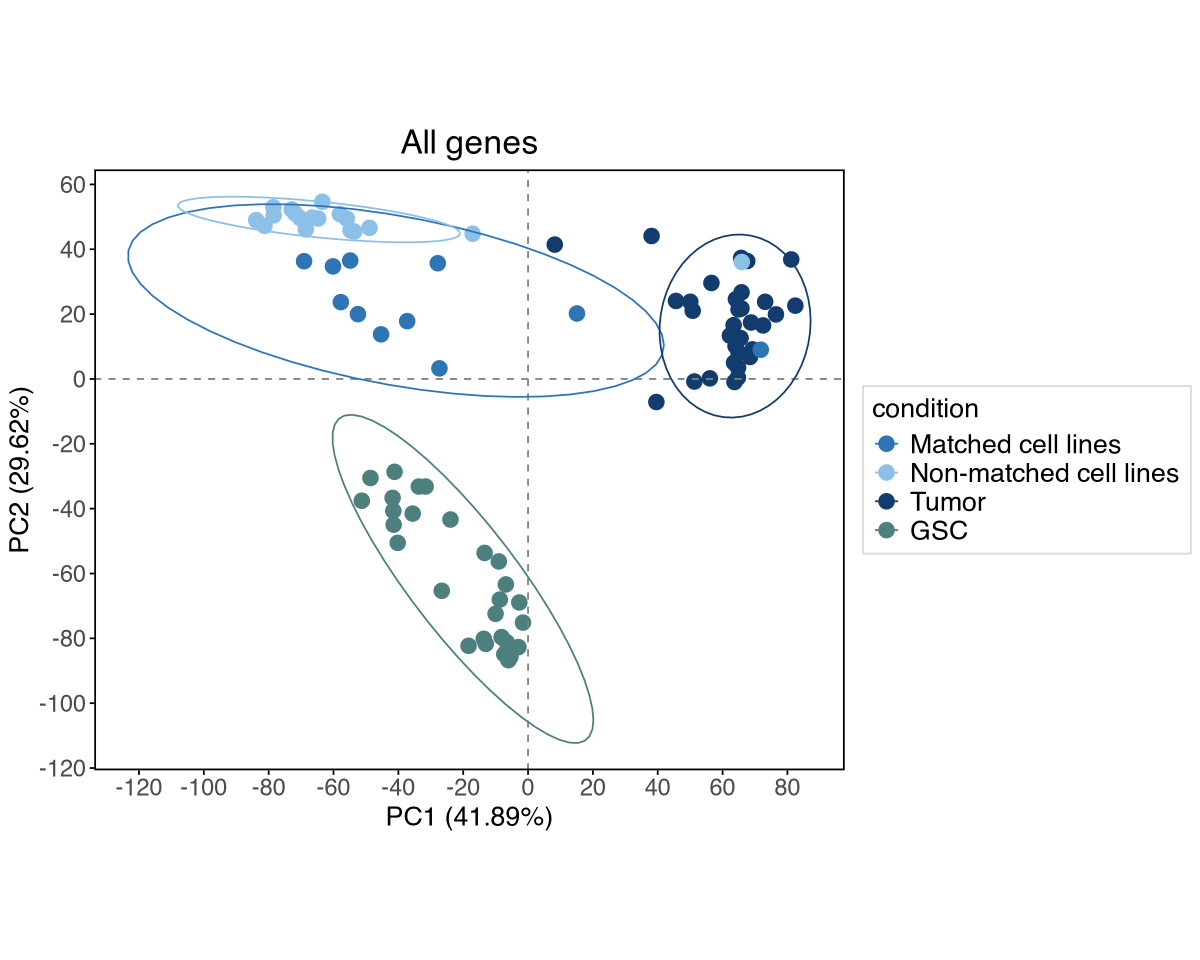

In [22]:
options(repr.plot.width=10, repr.plot.height=8)
pcaData <- plotPCA(vsd, intgroup="condition", returnData=TRUE)
pcaData$label <- rownames(pcaData)  
percentVar <- round(100 * attr(pcaData, "percentVar"), digits = 2)

p <- ggplot(pcaData, aes(PC1, PC2, color=condition)) + 
  geom_point(size=4) + 
  scale_color_manual(values = colors) +
  # geom_text_repel(aes(label = label), 
  #                 size=3, max.overlaps=20,
  #                 box.padding=0.2, 
  #                 point.padding=0.05,
  #                 segment.size=0.1, 
  #                 segment.color="black",
  #                 segment.alpha=0.6,
  #                 min.segment.length=0) +
  xlab(paste0("PC1 (",percentVar[1],"%)")) +
  ylab(paste0("PC2 (",percentVar[2],"%)")) + 
  labs(title = "All genes") +                 
  scale_x_continuous(breaks = seq(-200, 200, 20)) +
  scale_y_continuous(breaks = seq(-200, 200, 20)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") + 
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50") +
  coord_fixed() + 
  theme_minimal() + 
  theme(
    plot.title = element_text(size = 20, hjust = 0.5),  
    legend.text = element_text(size = 16),
    legend.title = element_text(size = 16),
    legend.background = element_rect(color = "gray85", linewidth = 0.5, fill = "white"),  
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    panel.grid = element_blank(),
    axis.ticks = element_line(),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1)) + stat_ellipse(aes(group=condition), level=0.95)
p

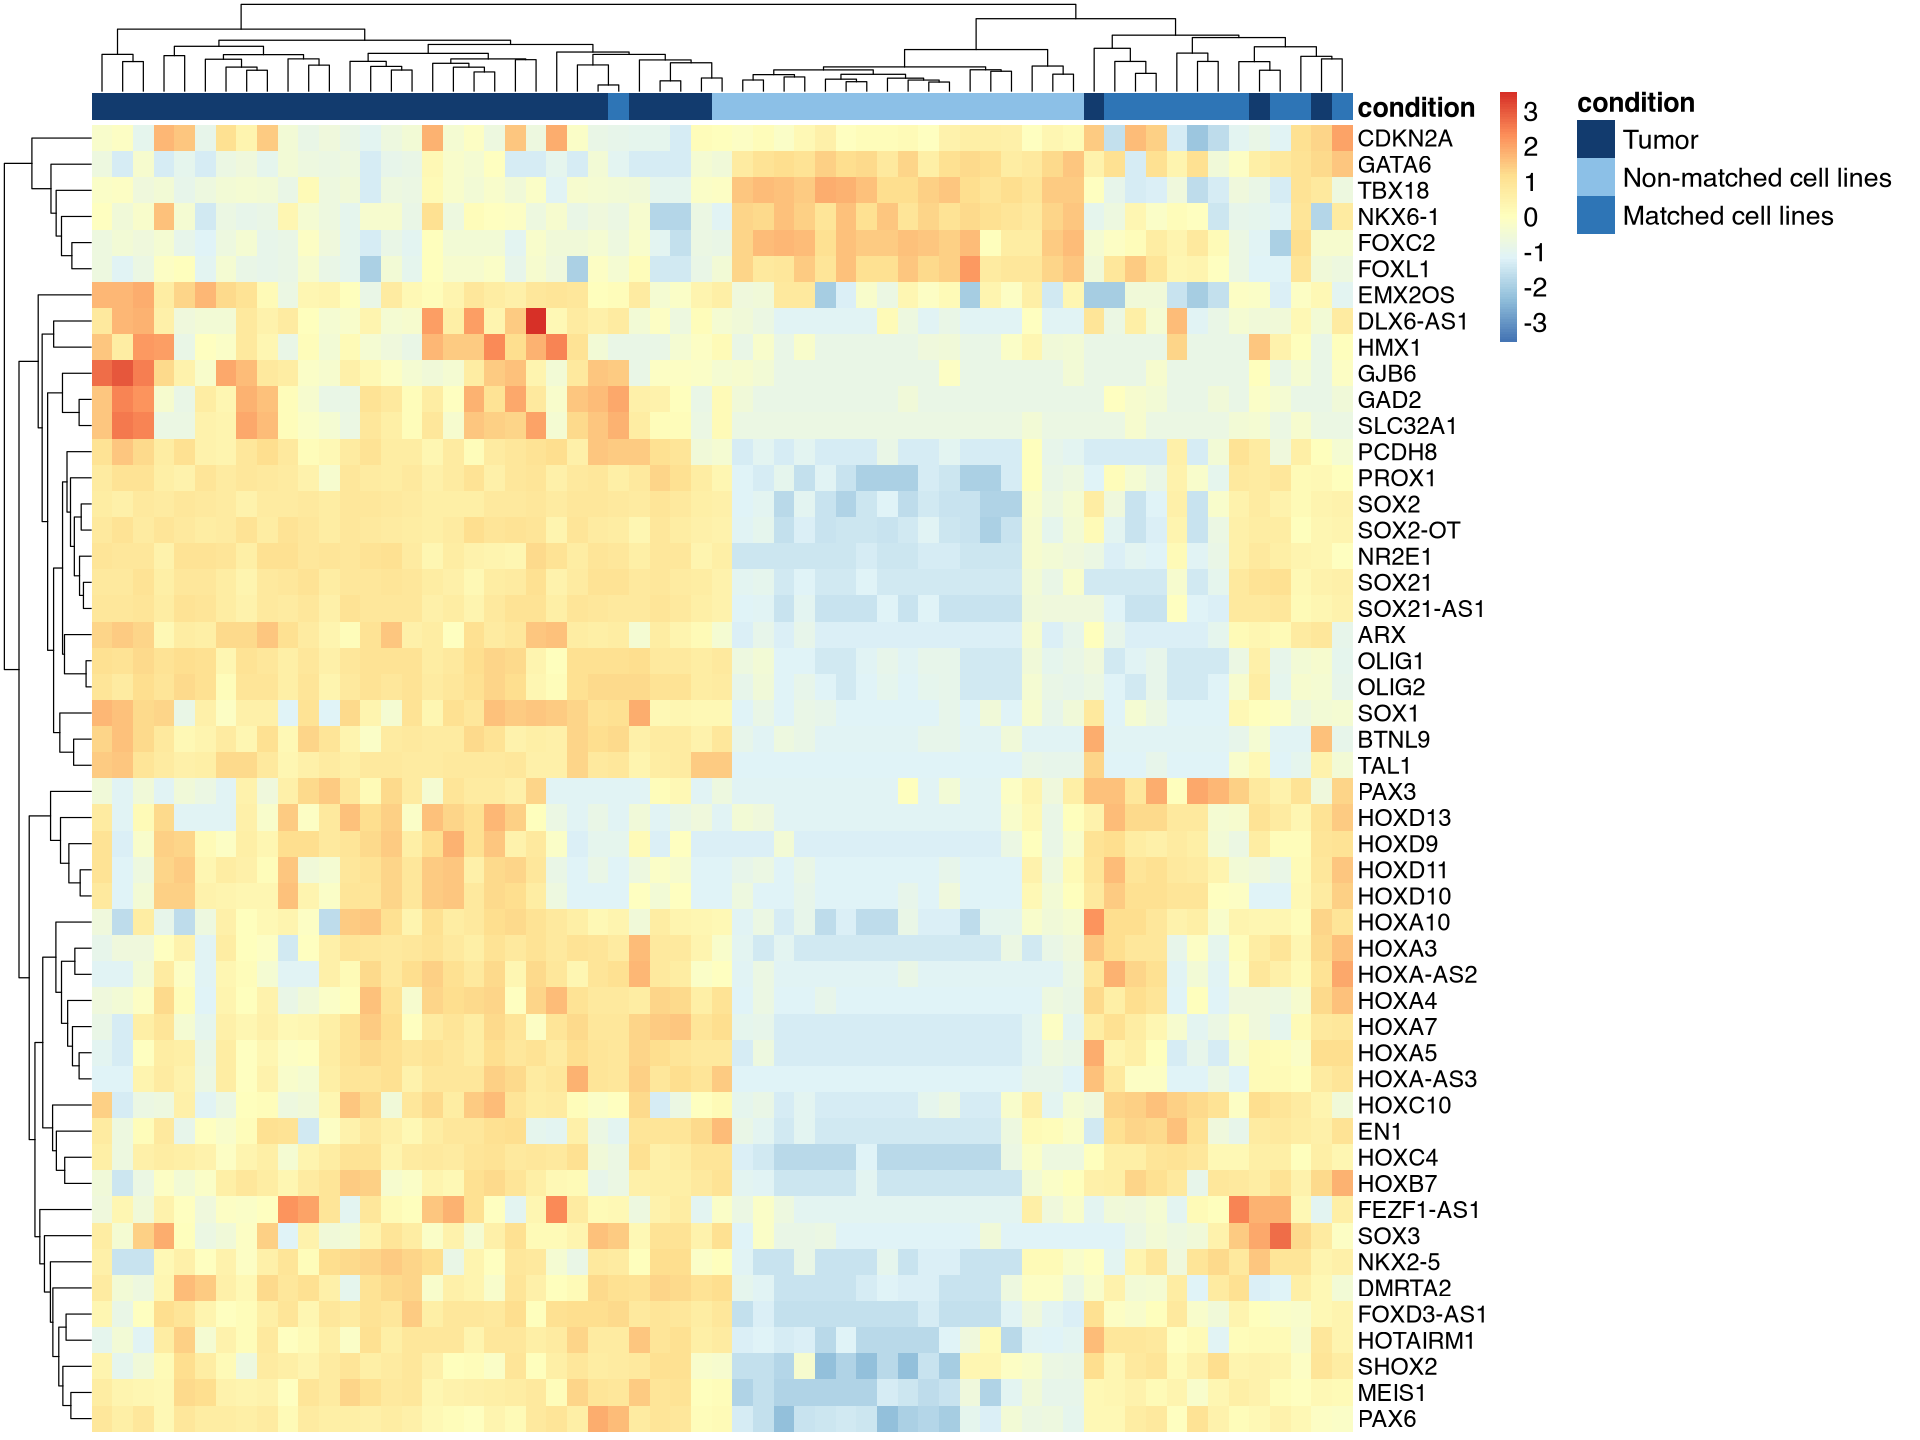

In [46]:
#Top variable genes
ann_colors <- list(
  condition = c(
    "Tumor" = "#123B6E",
    "Non-matched cell lines" = "#8CC0E7",
    "Matched cell lines" = "#2E75B6"
  )
)
options(repr.plot.width = 16, repr.plot.height = 12)

topVarGenes <- head(order(matrixStats::rowVars(assay(vsd), useNames = FALSE), decreasing = TRUE), 50)
gene_symbols <- annotation_table$symbol[match(rownames(vsd)[topVarGenes], annotation_table$ensembl_gene_id)]
names(gene_symbols) <- rownames(vsd)[topVarGenes]
mat <- assay(vsd)[topVarGenes, ]
rownames(mat) <- gene_symbols

pheatmap(
  mat,
  scale = "row",
  annotation_col = as.data.frame(colData(vsd))[, "condition", drop = FALSE],
  annotation_colors = ann_colors,
  fontsize = 16,
  fontsize_row = 14,
  show_colnames = FALSE
)

## boxplots (vst) ##

In [152]:
sample_annot <- as.data.frame(colData(dds)[, "condition", drop=FALSE]) 
sample_annot$sample <- rownames(sample_annot)
norm_mat <- assay(vsd)

In [153]:
genes_of_interest <- ress$ensembl_gene_id
valid_genes <- intersect(genes_of_interest, rownames(norm_mat))
submatrix <- norm_mat[valid_genes, ]

avg_expr <- colMeans(submatrix)

In [154]:
long_df <- data.frame(
  sample = names(avg_expr),
  expr = avg_expr,
  condition = sample_annot[names(avg_expr), "condition"]
)

In [155]:
head(long_df)

,sample,expr,condition
,<chr>,<dbl>,<fct>
G1,G1,4.004000,GSC
G23,G23,3.800882,GSC
G28,G28,3.930903,GSC
G61,G61,4.446235,GSC
G62,G62,3.956111,GSC
G83,G83,4.541396,GSC


In [156]:
desired_order <- c("Non-matched cell lines", "Matched cell lines", "GSC", "Tumor")
long_df$condition <- factor(long_df$condition, levels = desired_order)


In [157]:
my_comparisons <- list(
  c("Non-matched cell lines", "Matched cell lines"),
  c("Non-matched cell lines", "Tumor"),
  c("Matched cell lines", "Tumor") 
)

In [158]:
stat.test <- compare_means(
  expr ~ condition,
  data = long_df,
  method = "wilcox.test",
  p.adjust.method = "BH",
  comparisons = my_comparisons
)

In [159]:
stat.test.sig <- stat.test %>%
  filter(p.adj < 0.05) %>%
  mutate(y.position = seq(
    max(long_df$expr, na.rm = TRUE) * 1.05,
    max(long_df$expr, na.rm = TRUE) * 1.20,
    length.out = n()
  )) %>%
  mutate(y.position = y.position * 0.95)  

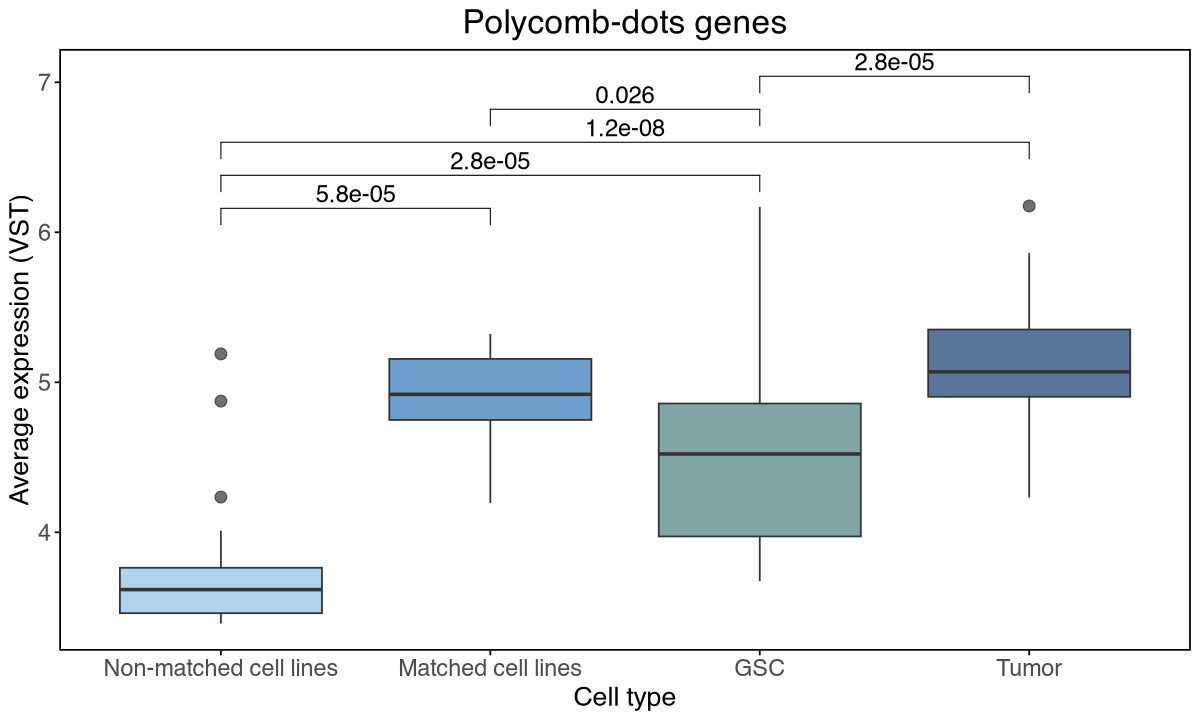

In [161]:
options(repr.plot.width = 10, repr.plot.height = 6)

p1 <- ggplot(long_df, aes(x = condition, y = expr, fill = condition)) +
  geom_boxplot(alpha = 0.7, outlier.size = 3, outlier.alpha = 0.7) +
  scale_fill_manual(values = colors) +
  theme_minimal() +
  labs(y = "Average expression (VST)", x = "Cell type", title = "Polycomb-dots genes") +
  theme(
    legend.position = "none",
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    panel.grid = element_blank(),
    axis.ticks = element_line(),
    panel.border = element_rect(color = "black", fill = NA, size = 1)
  )

p1 +
  stat_pvalue_manual(
    stat.test.sig,
    label = "p.adj",
    y.position = "y.position",
    size = 5,
    inherit.aes = FALSE
  )

In [30]:
gene_map <- data.frame(
  gene = c("ENSG00000139318", "ENSG00000181449", "ENSG00000106278"),
  symbol = c("DUSP6", "SOX2", "PTPRZ1")
)
gene_names <- c("ENSG00000139318", "ENSG00000181449", "ENSG00000106278")

In [31]:
# gene_map <- data.frame(
#   gene = c("ENSG00000108821", "ENSG00000213949", "ENSG00000115414"),
#   symbol = c("COL1A1", "ITGA1", "FN1")
# )
# gene_names <- c("ENSG00000108821", "ENSG00000213949", "ENSG00000115414")

gene_df <- as.data.frame(t(assay(vsd)[gene_names, ]))
gene_df$sample <- rownames(gene_df)
gene_df$condition <- colData(vsd)$condition[match(gene_df$sample, rownames(colData(vsd)))]

gene_long <- tidyr::pivot_longer(
  gene_df,
  cols = all_of(gene_names),
  names_to = "gene",
  values_to = "expr"
)

gene_long <- gene_long %>%
  left_join(gene_map, by = "gene")
desired_order <- c("Non-matched cell lines", "Matched cell lines", "GSC", "Tumor") 

gene_long$condition <- factor(gene_long$condition, levels = desired_order)

In [ ]:
stat.test <- gene_long %>%
  group_by(symbol) %>%
  wilcox_test(expr ~ condition, paired = FALSE) %>%
  adjust_pvalue(method = "BH") %>%
  add_significance("p.adj") %>%
  add_xy_position(
    x = "condition",
    step.increase = 0.2,
    scales = "free_y"  # важно для facet_wrap(scales = "free_y")
  ) %>%
  ungroup()

stat.test <- stat.test %>%
  mutate(p.adj_label = ifelse(
    p.adj < 0.001,                      
    formatC(p.adj, format = "e", digits = 2),  
    round(p.adj, 3)
  ))

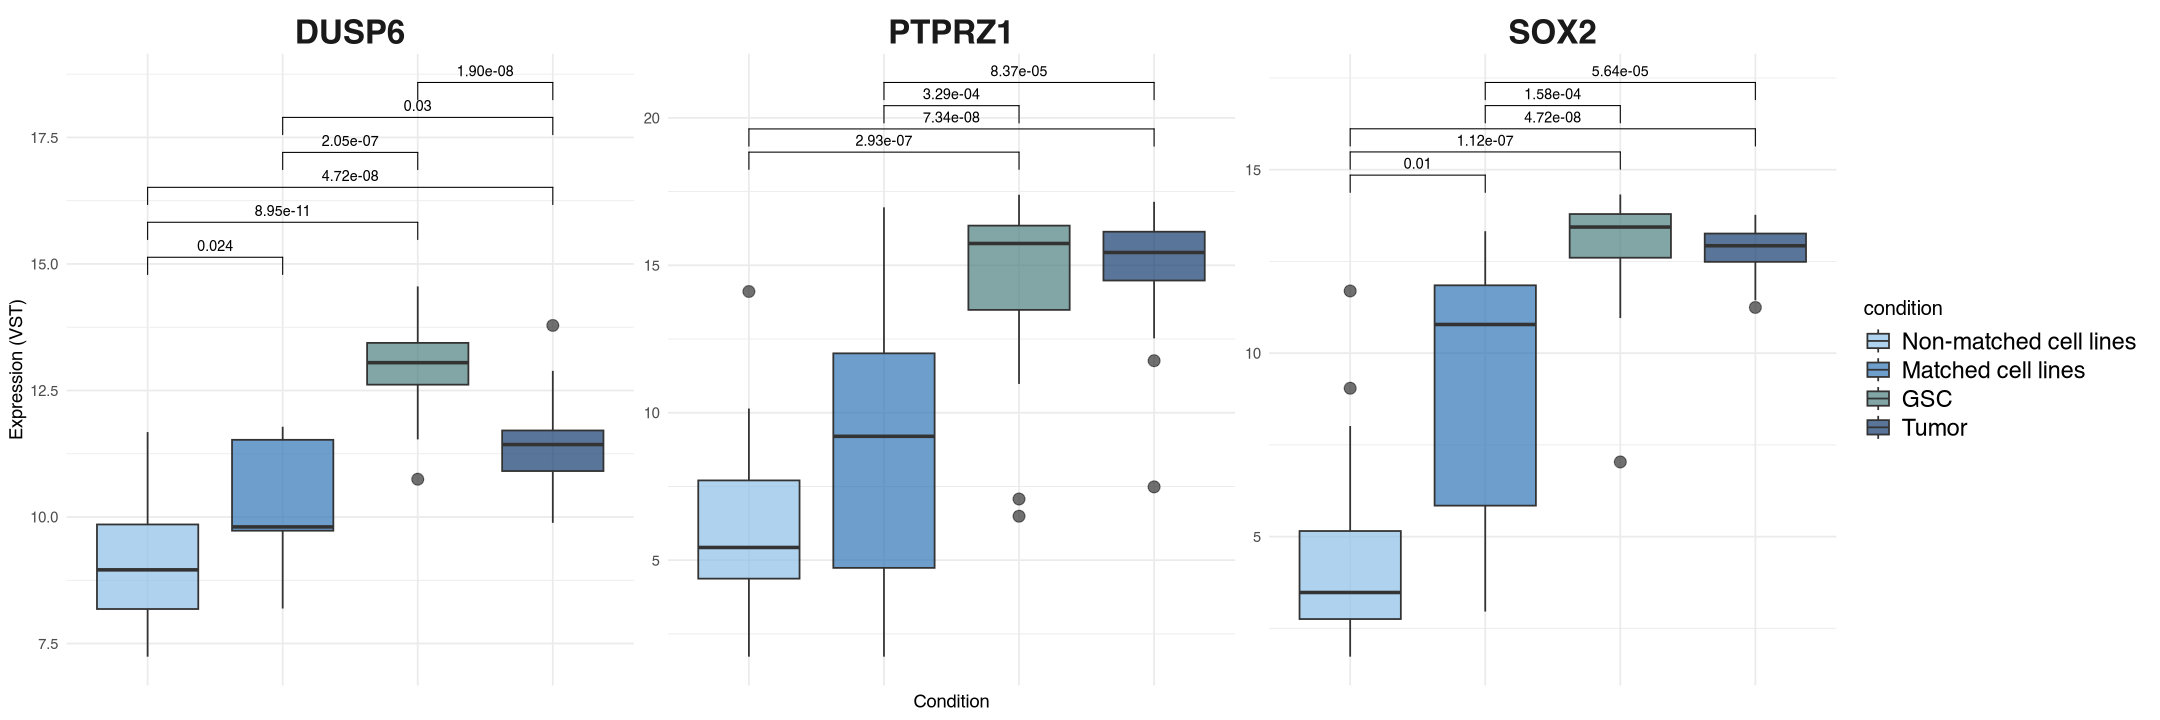

In [33]:
options(repr.plot.width = 18, repr.plot.height = 6)
ggplot(gene_long, aes(x = condition, y = expr)) +
  geom_boxplot(aes(fill = condition), alpha = 0.7, outlier.size = 3, outlier.alpha = 0.7) +
  facet_wrap(~symbol, scales = "free_y", nrow = 1) +
  scale_fill_manual(values = colors) +
  stat_pvalue_manual(
    stat.test,
    label = "p.adj_label",
    y.position = "y.position",  
    size = 3,
    hide.ns = TRUE
  ) +
  theme_minimal() +
  labs(x = "Condition", y = "Expression (VST)") + 
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank()
  ) + theme(
  legend.text = element_text(size = 14),  
  legend.title = element_text(size = 12), strip.text = element_text(size = 20, face = "bold") 
)

In [12]:
dds_factors <- DESeqDataSetFromMatrix(countData = counts_df, colData = colData, design = ~condition)

factor levels were dropped which had no samples

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [13]:
dds_factors <- estimateSizeFactors(dds_factors)
idx <- rowSums(counts(dds_factors, normalized=TRUE) >= 5 ) >= 5
dds_factors <- dds_factors[idx,]
dds_analysis <- DESeq(dds_factors)

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R

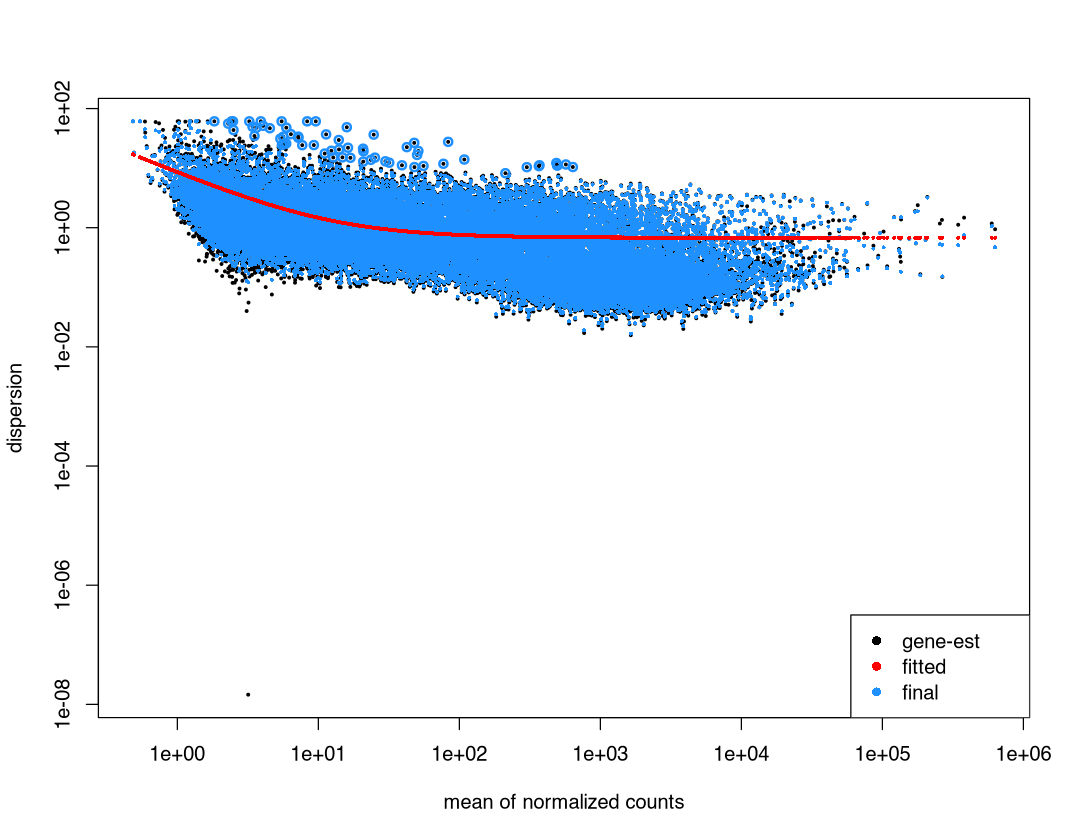

In [14]:
options(repr.plot.width=9, repr.plot.height=7)
disp_ests <- plotDispEsts(dds_analysis)

In [29]:
contrast <- c("condition", "Tumor", "Matched cell lines")

In [30]:
res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)

In [ ]:
res <- lfcShrink(dds_analysis, 
                     contrast=contrast, 
                     res=res_unshrunken, 
                     type='normal')
summary(res)

using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895



In [ ]:
padj.cutoff <- 0.05
lfc.cutoff <- 1
res_tb <- res %>% 
              data.frame() %>% 
              rownames_to_column(var="gene") %>% 
              as_tibble()
head(res_tb)

In [ ]:
sig <- res_tb %>% 
           dplyr::filter(padj < padj.cutoff & abs(log2FoldChange) >= lfc.cutoff)
nrow(sig)

In [ ]:
n_up <- sig %>% 
          dplyr::filter(log2FoldChange > 0) %>% 
          nrow()

n_down <- sig %>% 
            dplyr::filter(log2FoldChange < 0) %>% 
            nrow()

cat("Up-regulated:", n_up, "\n")
cat("Down-regulated:", n_down, "\n")
cat("Total:", nrow(sig), "\n")

In [122]:
sig_ensembl <- res_tb %>% 
  filter(padj < 0.05, log2FoldChange > 1) %>% pull(gene)

sig_map <- bitr(sig_ensembl, 
                fromType = "ENSEMBL", 
                toType = "ENTREZID", 
                OrgDb = org.Hs.eg.db)
sig_entrez <- unique(na.omit(sig_map$ENTREZID))

all_map <- bitr(res_tb$gene, 
                fromType = "ENSEMBL", 
                toType = "ENTREZID", 
                OrgDb = org.Hs.eg.db)

res_entrez <- unique(na.omit(all_map$ENTREZID))

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(sig_ensembl, fromType = "ENSEMBL", toType = "ENTREZID", :
"29.32% of input gene IDs are fail to map..."
'select()' returned 1:many mapping between keys and columns

Warning message in bitr(res_tb$gene, fromType = "ENSEMBL", toType = "ENTREZID", :
"32.22% of input gene IDs are fail to map..."


In [123]:
head(sig_entrez)

[1] "6405"  "1080"  "9957"  "90293" "3382"  "952"

In [124]:
head(res_entrez)

[1] "7105"  "64102" "8813"  "57147" "55732" "2268"

In [125]:
ekegg <- enrichKEGG(gene = sig_entrez,
                    organism = 'hsa',
                    pvalueCutoff = 0.05,
                    universe = res_entrez)

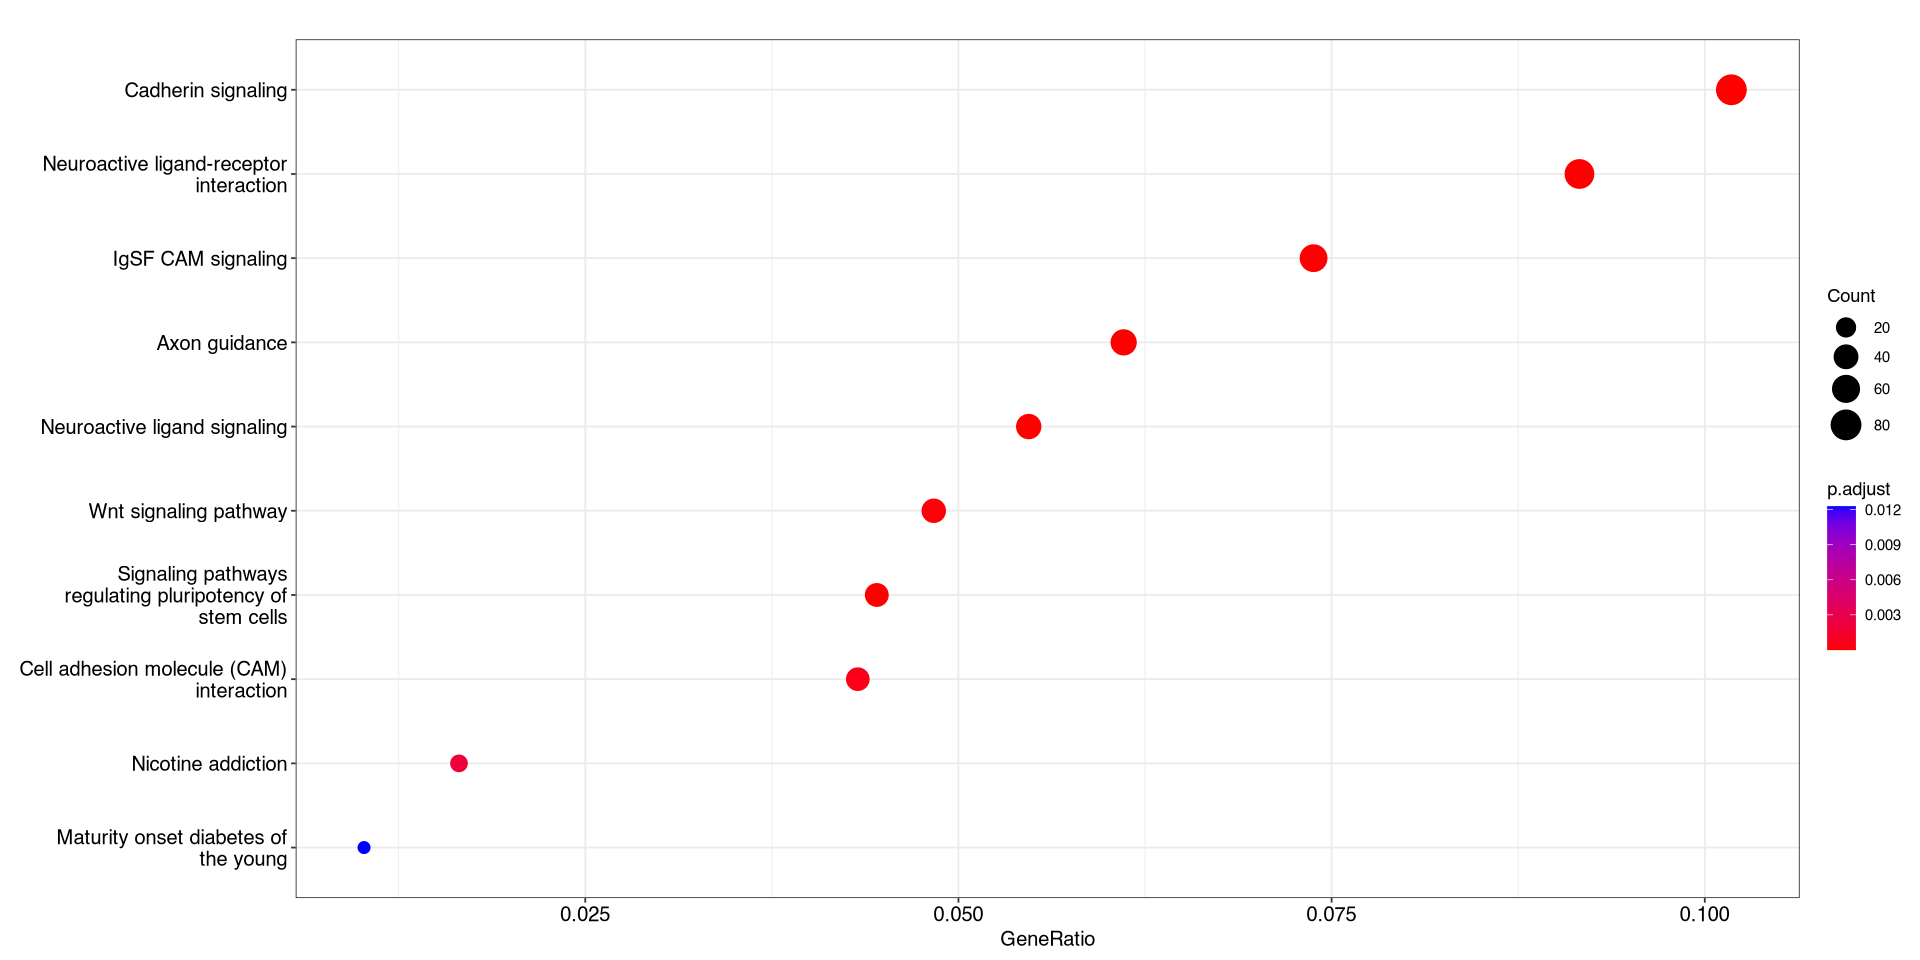

In [126]:
dotplot(ekegg)

In [127]:
gene_list <- res_tb$log2FoldChange
names(gene_list) <- res_tb$gene  # ENSEMBL ID
gene_list <- sort(gene_list, decreasing = TRUE)
gene_list <- gene_list[!is.na(gene_list)] 

# ENSEMBL → ENTREZID 
all_entrez <- bitr(names(gene_list), "ENSEMBL", "ENTREZID", org.Hs.eg.db)
gene_list_entrez <- gene_list[names(gene_list) %in% all_entrez$ENSEMBL]
names(gene_list_entrez) <- all_entrez$ENTREZID[match(names(gene_list_entrez), all_entrez$ENSEMBL)]
gene_list_entrez <- gene_list_entrez[!duplicated(names(gene_list_entrez))]

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(names(gene_list), "ENSEMBL", "ENTREZID", org.Hs.eg.db):
"32.22% of input gene IDs are fail to map..."


In [128]:
gseaKEGG <- gseKEGG(geneList = gene_list_entrez,              
                    pAdjustMethod = "fdr",
                    organism = "hsa", 
                    minGSSize = 10, 
                    pvalueCutoff = 0.05, 
                    verbose = FALSE, 
                    seed = TRUE )

[1] "Neuroactive ligand-receptor interaction"                      
 [2] "Neuroactive ligand signaling"                                 
 [3] "Nicotine addiction"                                           
 [4] "Amoebiasis"                                                   
 [5] "Cytoskeleton in muscle cells"                                 
 [6] "Cadherin signaling"                                           
 [7] "Protein processing in endoplasmic reticulum"                  
 [8] "GABAergic synapse"                                            
 [9] "Olfactory transduction"                                       
[10] "Chagas disease"                                               
[11] "Herpes simplex virus 1 infection"                             
[12] "Retrograde endocannabinoid signaling"                         
[13] "Wnt signaling pathway"                                        
[14] "Glutamatergic synapse"                                        
[15] "Autophagy - animal"                                           
[16] "Viral myocarditis"                                            
[17] "AGE-RAGE signaling pathway in diabetic complications"         
[18] "Cytokine-cytokine receptor interaction"                       
[19] "Pertussis"                                                    
[20] "Diabetic cardiomyopathy"                                      
[21] "Axon guidance"                                                
[22] "Terpenoid backbone biosynthesis"                              
[23] "Chemokine signaling pathway"                                  
[24] "Signaling pathways regulating pluripotency of stem cells"     
[25] "Staphylococcus aureus infection"                              
[26] "Hematopoietic cell lineage"                                   
[27] "Tuberculosis"                                                 
[28] "Rheumatoid arthritis"                                         
[29] "Viral protein interaction with cytokine and cytokine receptor"
[30] "Allograft rejection"                                          
[31] "Glycosaminoglycan biosynthesis - heparan sulfate / heparin"   
[32] "Graft-versus-host disease"                                    
[33] "Primary immunodeficiency"                                     
[34] "Focal adhesion"                                               
[35] "Intestinal immune network for IgA production"                 
[36] "RIG-I-like receptor signaling pathway"                        
[37] "Antigen processing and presentation"                          
[38] "Th1 and Th2 cell differentiation"                             
[39] "Vascular smooth muscle contraction"                           
[40] "TNF signaling pathway"

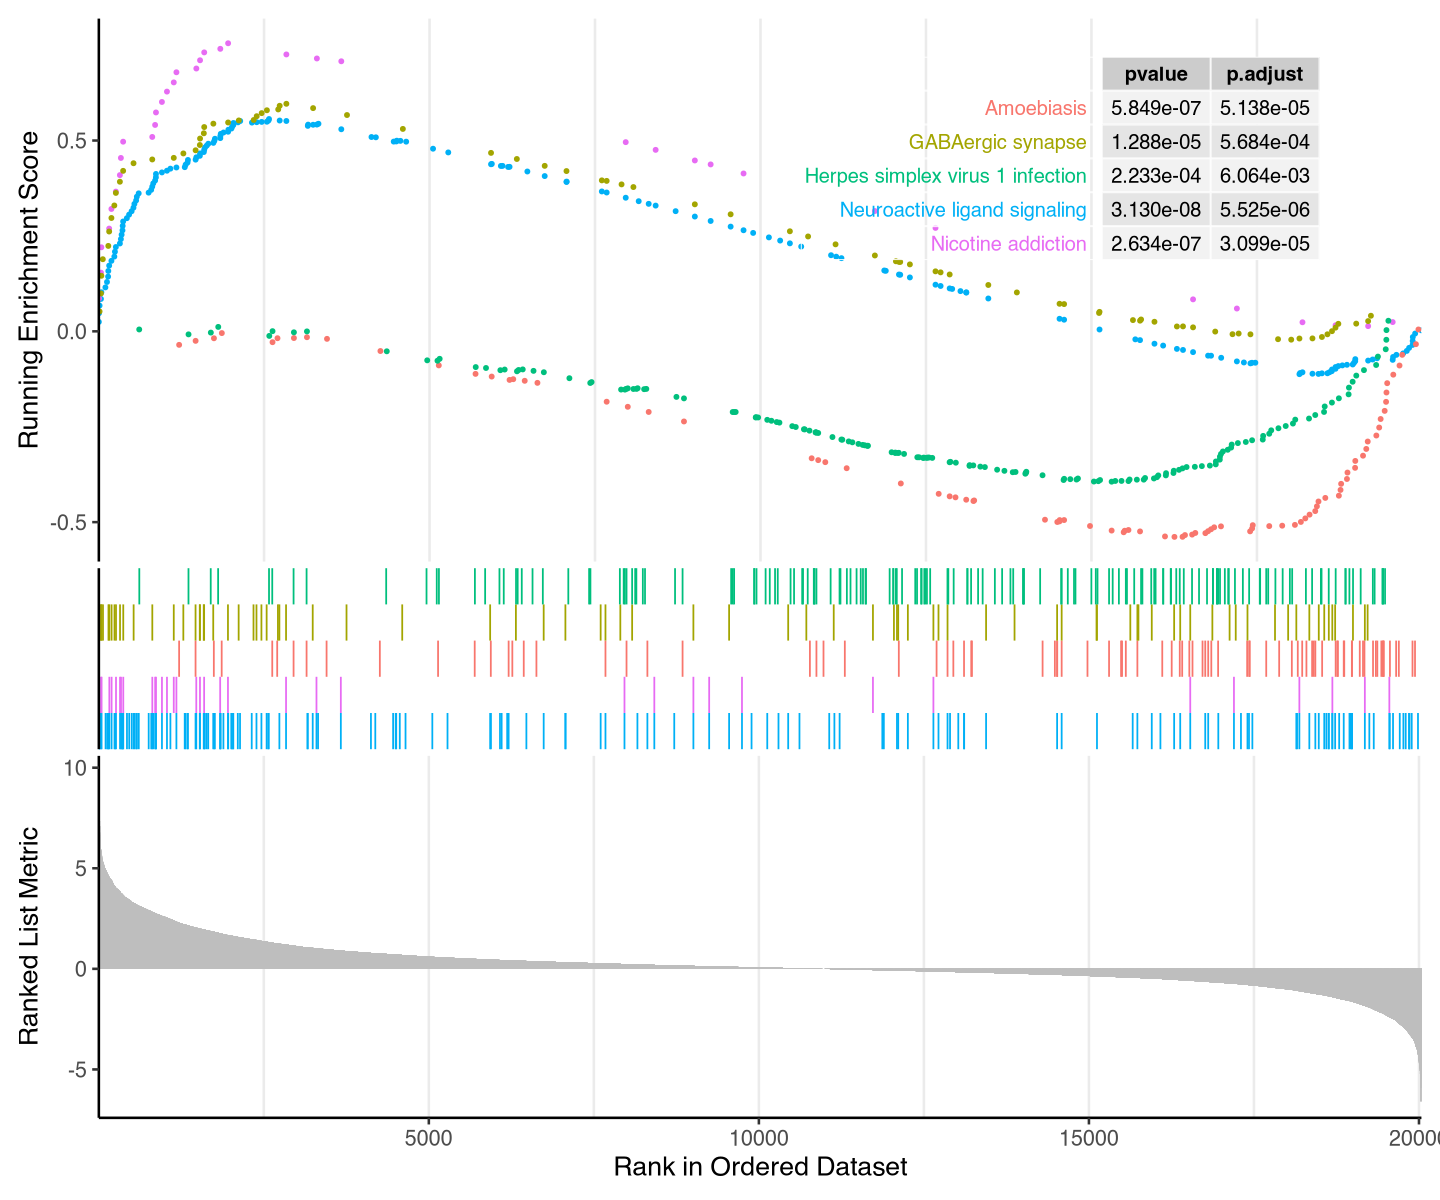

In [ ]:
#
options(repr.plot.width=12, repr.plot.height=10)
p <- gseaplot2(
  gseaKEGG, 
  geneSetID = path_ids,
  pvalue_table = TRUE, 
  ES_geom = "dot",
  base_size = 16
)

p

In [95]:
annotation_unique <- annotation_table[!duplicated(annotation_table$ensembl_gene_id), ]
deseq_annotated <- merge(sig, annotation_unique, 
                        by.x="gene", by.y="ensembl_gene_id", all.x=TRUE)

In [96]:
hs <- org.Hs.eg.db
my.symbols <- res_tb$gene
map <- AnnotationDbi::select(
  hs,
  keys = my.symbols,
  columns = c("ENTREZID", "SYMBOL", "ENSEMBL"),
  keytype = "ENSEMBL"
)
res_tb <- left_join(res_tb, map, by = c("gene" = "ENSEMBL"))

'select()' returned 1:many mapping between keys and columns



In [97]:
res_tb <- res_tb[!duplicated(res_tb$gene),]
sig <- res_tb %>% dplyr::filter(gene %in% sig$gene)

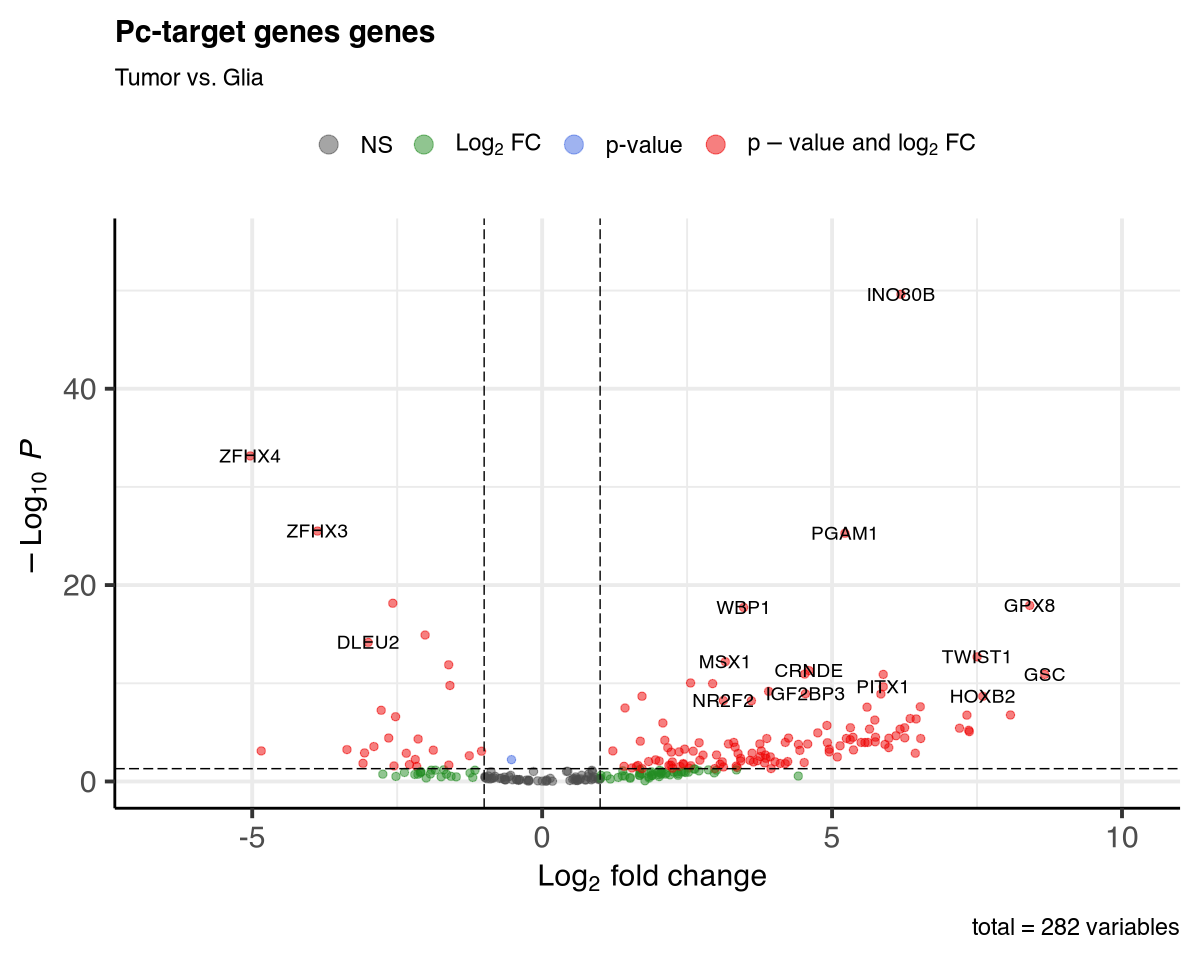

In [99]:
top_genes <- res_tb$SYMBOL[res_tb$padj < 0.00000001 & abs(res_tb$log2FoldChange) > 3]
options(repr.plot.width = 10, repr.plot.height = 8)
p1 <- EnhancedVolcano(
  res_tb,
  lab = res_tb$SYMBOL,
  selectLab = top_genes,
  x = 'log2FoldChange',
  y = 'padj',
  pCutoff = 0.05,
  FCcutoff = 1,
  labSize = 4, title = "Pc-target genes genes", subtitle = "Tumor vs. Glia", 
)
p1

**Gene Ontology analysis**

In [133]:
res_up <- res[which(res$log2FoldChange > 1 & res$padj < 0.05), ]
geneListUp <- rownames(res_up)

In [134]:
res_down <- res[which(res$log2FoldChange < -1 & res$padj < 0.05), ]
geneListDown <- rownames(res_down)

In [135]:
ego_up <- enrichGO(gene = geneListUp, 
                    universe = rownames(res),
                    keyType = "ENSEMBL",
                    OrgDb = org.Hs.eg.db, 
                    ont = "ALL",
                    pAdjustMethod = "BH", 
                    pvalueCutoff = 0.05)

ego_down <- enrichGO(gene = geneListDown,
                                universe = rownames(res),
                                keyType = "ENSEMBL",
                                OrgDb = org.Hs.eg.db, 
                                ont = "ALL",
                                pAdjustMethod = "BH", 
                                pvalueCutoff = 0.05)

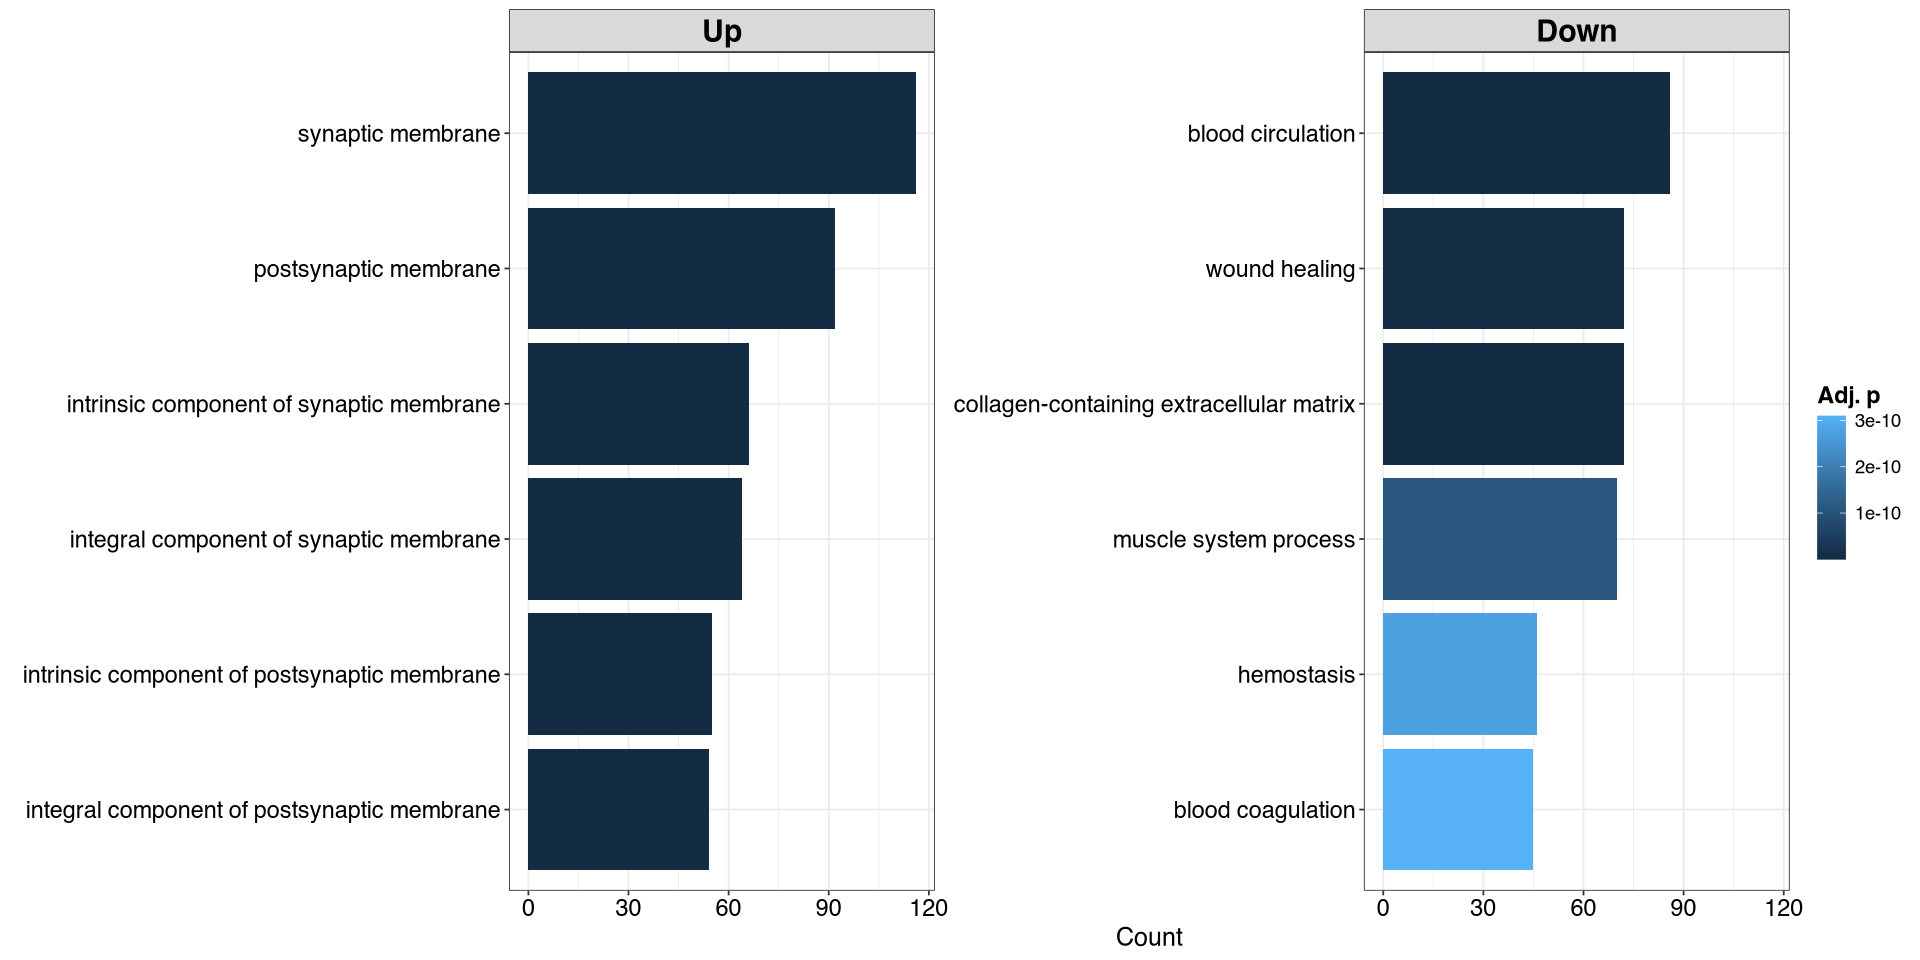

In [136]:
options(repr.plot.width = 16, repr.plot.height = 8)

up_df <- as.data.frame(ego_up) %>%
  mutate(direction = "Up")
down_df <- as.data.frame(ego_down) %>%
  mutate(direction = "Down")

plot_df <- bind_rows(up_df, down_df) %>%
  mutate(direction = factor(direction, levels = c("Up", "Down"))) %>%
  group_by(direction) %>%
  slice_min(order_by = p.adjust, n = 6, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(Description = fct_reorder(Description, Count))

ggplot(plot_df, aes(x = Count, y = Description, fill = p.adjust)) +
  geom_col() +
  facet_wrap(~direction, nrow = 1, scales = "free_y") +
  labs(x = "Count", y = NULL, fill = "Adj. p") +
  theme_bw() +
  theme(
    strip.text = element_text(size = 18, face = "bold", color = "black"),
    axis.text = element_text(size = 14, color = "black"),
    axis.title = element_text(size = 15, color = "black"),
    legend.title = element_text(size = 14, face = "bold", color = "black"),
    legend.text = element_text(size = 11, color = "black")
  )